In [ ]:
import os
import numpy as np
from PIL import Image
import csv

# Define paths
AUTH_DIR = "recodai-luc-scientific-image-forgery-detection/train_images/authentic"
FORGED_DIR = "recodai-luc-scientific-image-forgery-detection/train_images/forged"
MASKS_DIR = "recodai-luc-scientific-image-forgery-detection/train_masks"

# Prepare list of .npy masks in mask dir
mask_filenames = [f for f in os.listdir(MASKS_DIR) if f.endswith(".npy")]
mask_filenames.sort()
csv_filename = "mask_image_summary.csv"

def find_image_for_basename(basename):
    # Try both authentic and forged
    for dir_path in [AUTH_DIR, FORGED_DIR]:
        img_path = os.path.join(dir_path, basename)
        if os.path.exists(img_path):
            return img_path
    return None

with open(csv_filename, mode='w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow([
        "mask_name",
        "mask_shape",
        "mask_dtype",
        "mask_unique",
        "mask_min",
        "mask_max",
        "image_path",
        "image_size",
        "image_mode"
    ])
    for mask_fname in mask_filenames:
        mask_path = os.path.join(MASKS_DIR, mask_fname)
        mask = np.load(mask_path)
        # Mask stats
        mask_shape = mask.shape
        mask_dtype = str(mask.dtype)
        mask_unique = np.unique(mask)
        mask_min = mask.min()
        mask_max = mask.max()
        # Print as per instruction
        print(f'{mask_fname}: shape={mask_shape}, dtype={mask_dtype}, unique={mask_unique}, min={mask_min}, max={mask_max}')
        # Match image
        base_no_ext = os.path.splitext(mask_fname)[0] + ".png"
        img_path = find_image_for_basename(base_no_ext)
        if img_path is not None:
            with Image.open(img_path) as im:
                img_size = im.size
                img_mode = im.mode
        else:
            img_path = ""
            img_size = ""
            img_mode = ""
        writer.writerow([
            mask_fname,
            mask_shape,
            mask_dtype,
            "|".join(str(v) for v in mask_unique),
            mask_min,
            mask_max,
            img_path,
            img_size,
            img_mode
        ])

In [1]:
# Define paths
AUTH_DIR = "recodai-luc-scientific-image-forgery-detection/test_images"
FORGED_DIR = "recodai-luc-scientific-image-forgery-detection/test_images"
MASKS_DIR = "predicted_masks"

In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def plot_image_forged_mask(image_base_name, authentic_dir, forged_dir, mask_dir):
    """
    Print image sizes and mask shapes for original, forged, and mask files.
    Also plots original, forged, mask, and mask overlay images, as before.
    """
    # Ensure base name without extension
    if image_base_name.endswith(".png"):
        base = os.path.splitext(image_base_name)[0]
    else:
        base = image_base_name

    authentic_img_path = os.path.join(authentic_dir, f"{base}.png")
    forged_img_path   = os.path.join(forged_dir, f"{base}.png")
    mask_path         = os.path.join(mask_dir, f"{base}.npy")

    # Load images
    orig_img, forged_img, mask_img = None, None, None

    if os.path.exists(authentic_img_path):
        orig_img = Image.open(authentic_img_path)
        print(f"Original image size: {orig_img.size}")
    else:
        print(f"Original image not found: {authentic_img_path}")

    if os.path.exists(forged_img_path):
        forged_img = Image.open(forged_img_path)
        print(f"Forged image size: {forged_img.size}")
    else:
        print(f"Forged image not found: {forged_img_path}")

    if os.path.exists(mask_path):
        mask_img = np.load(mask_path)
        print(f"Mask shape: {mask_img.shape}")
        if mask_img.ndim == 3 and mask_img.shape[0] == 1:
            mask_img = mask_img[0]
        elif mask_img.ndim == 3 and mask_img.shape[0] <= 3:
            mask_img = mask_img[0]
        if mask_img.ndim > 2:
            mask_img = np.squeeze(mask_img)
    else:
        print(f"Mask file not found: {mask_path}")

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    plt.subplots_adjust(wspace=0.2)

    if orig_img is not None:
        axes[0].imshow(orig_img)
        axes[0].set_title("Original")
    else:
        axes[0].text(0.5, 0.5, "Not Found", ha='center', va='center', fontsize=16)
        axes[0].set_title("Original (missing)")

    if forged_img is not None:
        axes[1].imshow(forged_img)
        axes[1].set_title("Forged")
    else:
        axes[1].text(0.5, 0.5, "Not Found", ha='center', va='center', fontsize=16)
        axes[1].set_title("Forged (missing)")

    if mask_img is not None:
        axes[2].imshow(mask_img, cmap='gray' if mask_img.ndim == 2 else None)
        axes[2].set_title("Mask")
    else:
        axes[2].text(0.5, 0.5, "Not Found", ha='center', va='center', fontsize=16)
        axes[2].set_title("Mask (missing)")

    if forged_img is not None and mask_img is not None:
        mask_for_overlay = mask_img
        if hasattr(forged_img, "size") and hasattr(mask_for_overlay, "shape"):
            img_w, img_h = forged_img.size
            mask_h, mask_w = mask_for_overlay.shape[-2], mask_for_overlay.shape[-1]
            if (img_w, img_h) != (mask_w, mask_h):
                mask_pil = Image.fromarray((mask_for_overlay * 255).astype(np.uint8)) if mask_for_overlay.max() <= 1 else Image.fromarray(mask_for_overlay.astype(np.uint8))
                mask_pil = mask_pil.resize((img_w, img_h), resample=Image.NEAREST)
                mask_for_overlay = np.array(mask_pil)
        axes[3].imshow(forged_img)
        axes[3].imshow(mask_for_overlay, cmap='jet', alpha=0.4)
        axes[3].set_title("Forged + Mask overlay")
    else:
        axes[3].text(0.5, 0.5, "Not Found", ha='center', va='center', fontsize=16)
        axes[3].set_title("Overlay (missing)")

    for ax in axes: ax.axis('off')
    plt.show()


Original image size: (2008, 1444)
Forged image size: (2008, 1444)
Mask shape: (1444, 2008, 1)


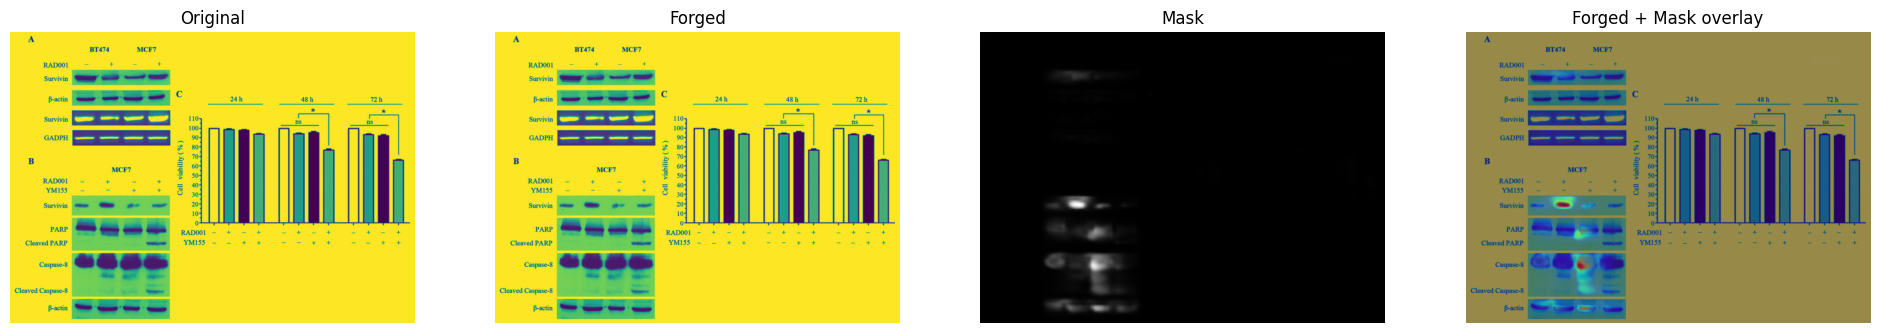

In [17]:
plot_image_forged_mask(
    "45",
    authentic_dir=AUTH_DIR,
    forged_dir=FORGED_DIR,
    mask_dir=MASKS_DIR
)

Original image size: (1000, 666)
Forged image size: (1000, 666)
Mask shape: (1, 666, 1000)


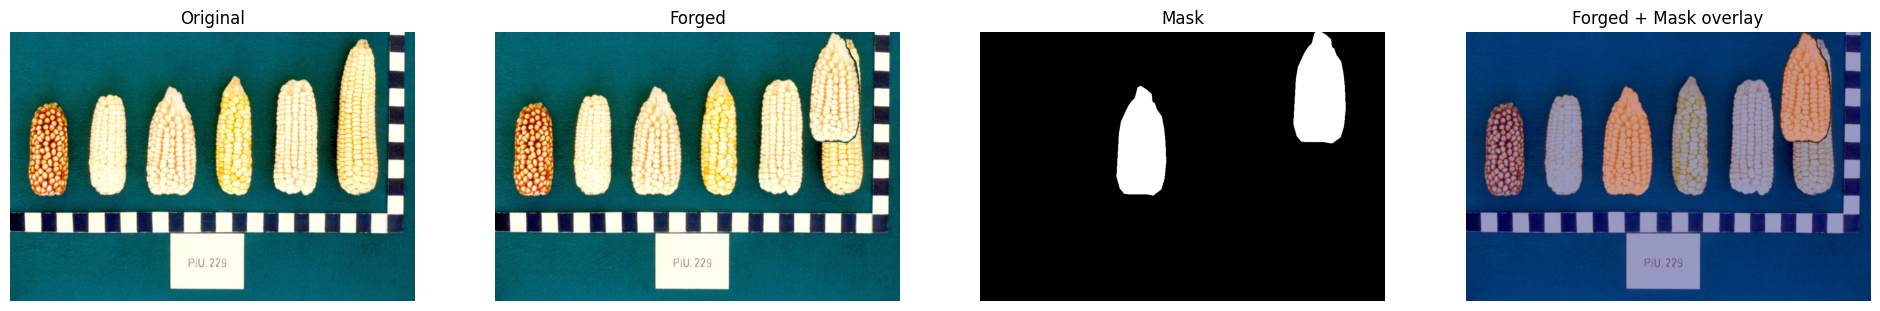

In [9]:
plot_image_forged_mask(
    "210",
    authentic_dir="recodai-luc-scientific-image-forgery-detection/train_images/authentic",
    forged_dir="recodai-luc-scientific-image-forgery-detection/train_images/forged",
    mask_dir="recodai-luc-scientific-image-forgery-detection/train_masks"
)

Original image size: (320, 256)
Forged image size: (320, 256)
Mask shape: (1, 256, 320)


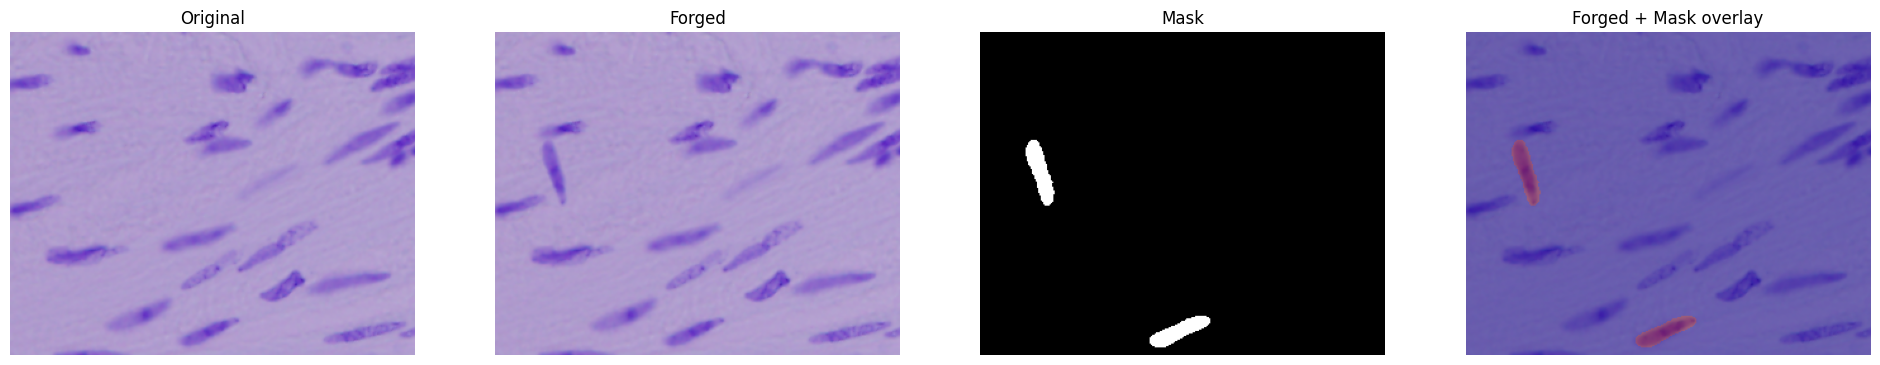

In [19]:
plot_image_forged_mask(
    "10017",
    authentic_dir="recodai-luc-scientific-image-forgery-detection/train_images/authentic",
    forged_dir="recodai-luc-scientific-image-forgery-detection/train_images/forged",
    mask_dir="recodai-luc-scientific-image-forgery-detection/train_masks"
)

Original mask shape: (2, 1200, 1600)
Resolved mask shape: (1200, 1600, 2)


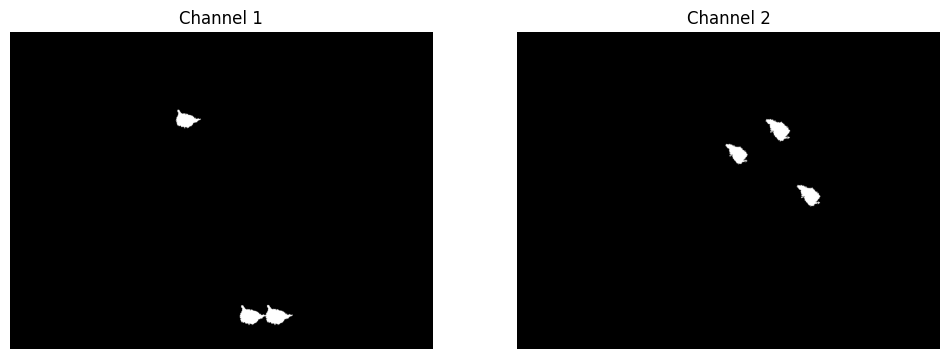

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def plot_mask_channels(image_id, mask_dir):
    mask_path = f"{mask_dir}/{image_id}.npy"
    mask = np.load(mask_path)
    print("Original mask shape:", mask.shape)  # Print the mask shape

    # Handle mask to shape (H, W, C), supporting 1, 2, or 3 channels
    if mask.ndim == 2:
        # Single channel, shape (H, W)
        mask = np.expand_dims(mask, axis=-1)
    elif mask.ndim == 3:
        # Could be (H, W, C) or (C, H, W)
        if mask.shape[0] in {1, 2, 3} and mask.shape[2] not in {1, 2, 3}:
            # Assume (C, H, W) -> (H, W, C)
            mask = np.transpose(mask, (1, 2, 0))
        elif mask.shape[2] in {1, 2, 3}:
            # Already (H, W, C)
            pass
        else:
            # Unexpected, fall back to adding a channel
            mask = np.expand_dims(mask, axis=-1)

    n_channels = mask.shape[-1]

    print("Resolved mask shape:", mask.shape)  # Print resolved mask shape

    plt.figure(figsize=(6 * n_channels, 5))
    for i in range(n_channels):
        plt.subplot(1, n_channels, i+1)
        plt.imshow(mask[..., i], cmap='gray')
        plt.title(f'Channel {i+1}')
        plt.axis('off')
    plt.show()

# plot example mask channels
plot_mask_channels(
    "4460",
    mask_dir="recodai-luc-scientific-image-forgery-detection/train_masks"
)
